Combined shape: (1291362, 44)
Shape after cleaning: (1291362, 44)
Train: (815174, 44)
Val: (158856, 44)
Test: (317332, 44)


C:\Users\Hari\AppData\Local\Temp\ipykernel_23584\3081546814.py:155: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  s = skew(values)
C:\Users\Hari\AppData\Local\Temp\ipykernel_23584\3081546814.py:156: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  k = kurtosis(values)


X_train: (10811, 360)
X_val: (2107, 360)
X_test: (4208, 360)
Training until validation scores don't improve for 15 rounds
[25]	train's multi_logloss: 1.13224	validation's multi_logloss: 1.38067
[50]	train's multi_logloss: 0.731184	validation's multi_logloss: 1.02531
[75]	train's multi_logloss: 0.513409	validation's multi_logloss: 0.834285
[100]	train's multi_logloss: 0.37847	validation's multi_logloss: 0.732206
[125]	train's multi_logloss: 0.291041	validation's multi_logloss: 0.653917
[150]	train's multi_logloss: 0.232423	validation's multi_logloss: 0.60071
[175]	train's multi_logloss: 0.19038	validation's multi_logloss: 0.539435
[200]	train's multi_logloss: 0.160518	validation's multi_logloss: 0.513163
[225]	train's multi_logloss: 0.137719	validation's multi_logloss: 0.489872
[250]	train's multi_logloss: 0.119816	validation's multi_logloss: 0.468635
[275]	train's multi_logloss: 0.105091	validation's multi_logloss: 0.460347
[300]	train's multi_logloss: 0.0938228	validation's multi_logl

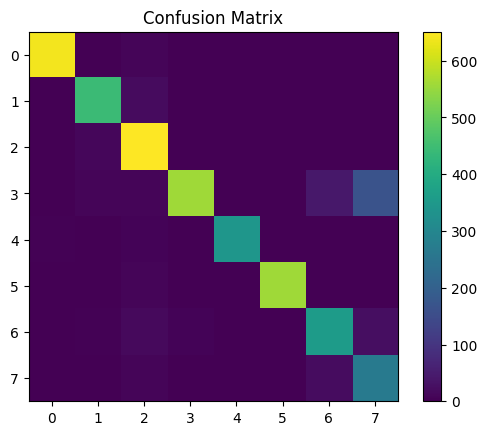

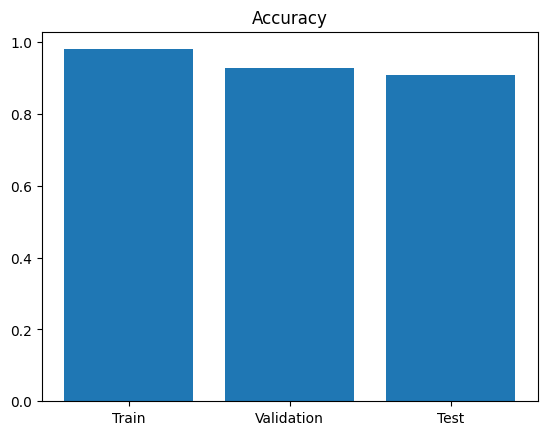

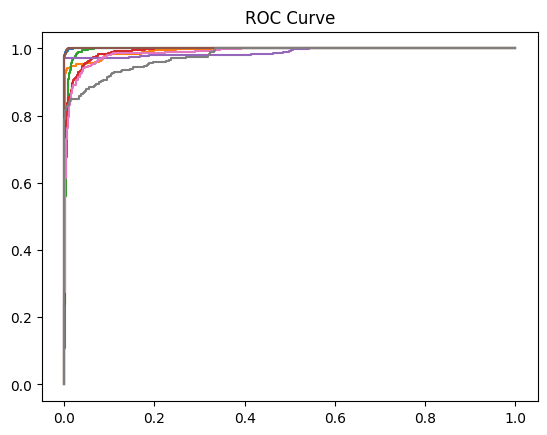

In [1]:
#LightGBM code for HAR 
import pandas as pd
import numpy as np
import lightgbm as lgb

from scipy.stats import skew, kurtosis

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Column names

columns = [
    "timestamp", "activityID", "heart_rate",

    "hand_temp", "hand_acc16_x", "hand_acc16_y", "hand_acc16_z",
    "hand_acc6_x", "hand_acc6_y", "hand_acc6_z",
    "hand_gyro_x", "hand_gyro_y", "hand_gyro_z",
    "hand_mag_x", "hand_mag_y", "hand_mag_z",
    "hand_ori1", "hand_ori2", "hand_ori3", "hand_ori4",

    "chest_temp", "chest_acc16_x", "chest_acc16_y", "chest_acc16_z",
    "chest_acc6_x", "chest_acc6_y", "chest_acc6_z",
    "chest_gyro_x", "chest_gyro_y", "chest_gyro_z",
    "chest_mag_x", "chest_mag_y", "chest_mag_z",
    "chest_ori1", "chest_ori2", "chest_ori3", "chest_ori4",

    "ankle_temp", "ankle_acc16_x", "ankle_acc16_y", "ankle_acc16_z",
    "ankle_acc6_x", "ankle_acc6_y", "ankle_acc6_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "ankle_ori1", "ankle_ori2", "ankle_ori3", "ankle_ori4"
]

# Settings

data_path = r"C:\Users\Hari\Desktop\Artificial intelligence\PAMAP2_Dataset\PAMAP2_Dataset\Protocol"

subject_files = {
    101: "subject101.dat",
    102: "subject102.dat",
    103: "subject103.dat",
    104: "subject104.dat",
    105: "subject105.dat",
    106: "subject106.dat",
    107: "subject107.dat",
    108: "subject108.dat",
    109: "subject109.dat"
}

valid_activities = [1, 2, 3, 4, 5, 6, 12, 13]

train_subjects = [101, 102, 103, 105, 108, 109]
val_subjects   = [104]
test_subjects  = [106, 107]

# Load data

all_data = []

for subject_id in subject_files:
    file_name = subject_files[subject_id]
    file_path = f"{data_path}\\{file_name}"

    df = pd.read_csv(file_path, sep=r"\s+", header=None, names=columns)

    df = df[df["activityID"].isin(valid_activities)]

    df["subject_id"] = subject_id
    df["session"] = 1

    all_data.append(df)


cleaned_data = []

for df in all_data:
    orientation_cols = []
    for col in df.columns:
        if "ori" in col:
            orientation_cols.append(col)

    df = df.drop(columns=orientation_cols)

    for col in df.columns:
        if col not in ["activityID", "subject_id", "session"]:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(np.float32)

    df["activityID"] = df["activityID"].astype(np.int16)
    df["subject_id"] = df["subject_id"].astype(np.int16)
    df["session"] = df["session"].astype(np.int8)

    cleaned_data.append(df)


data = pd.concat(cleaned_data, ignore_index=True)

print("Combined shape:", data.shape)

# Missing values

data.replace([np.inf, -np.inf], np.nan, inplace=True)

data = data.sort_values(["subject_id", "session", "timestamp"])
data = data.reset_index(drop=True)

feature_cols = []
for col in data.columns:
    if col not in ["timestamp", "activityID", "subject_id", "session"]:
        feature_cols.append(col)

grouped = data.groupby(["subject_id", "session"])

for col in feature_cols:
    data[col] = grouped[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

for col in feature_cols:
    data[col] = grouped[col].transform(
        lambda x: x.ffill().bfill()
    )

data = data.dropna().reset_index(drop=True)

print("Shape after cleaning:", data.shape)

# Split

train_data = data[data["subject_id"].isin(train_subjects)]
val_data   = data[data["subject_id"].isin(val_subjects)]
test_data  = data[data["subject_id"].isin(test_subjects)]

print("Train:", train_data.shape)
print("Val:", val_data.shape)
print("Test:", test_data.shape)

# Feature extraction

def extract_features_from_window(window_df, feature_cols):
    row = {}

    for col in feature_cols:
        values = window_df[col].values.astype(np.float32)

        row[col + "_mean"] = np.mean(values)
        row[col + "_std"] = np.std(values)
        row[col + "_min"] = np.min(values)
        row[col + "_max"] = np.max(values)
        row[col + "_median"] = np.median(values)
        row[col + "_range"] = np.max(values) - np.min(values)
        row[col + "_energy"] = np.sum(values ** 2) / len(values)

        s = skew(values)
        k = kurtosis(values)

        if np.isnan(s):
            s = 0.0
        if np.isnan(k):
            k = 0.0

        row[col + "_skew"] = s
        row[col + "_kurtosis"] = k

    return row

# Windowing

def create_window_features(df, feature_cols, window_size=150, step_size=75):
    X_rows = []
    y_rows = []

    grouped = df.groupby(["subject_id", "session", "activityID"])

    for key in grouped.groups:
        subject_id, session, activity_id = key
        group = grouped.get_group(key).sort_values("timestamp").reset_index(drop=True)

        start = 0
        while start + window_size <= len(group):
            end = start + window_size
            window_df = group.iloc[start:end]

            X_rows.append(extract_features_from_window(window_df, feature_cols))
            y_rows.append(activity_id)

            start += step_size

    return pd.DataFrame(X_rows), np.array(y_rows, dtype=np.int16)

X_train, y_train = create_window_features(train_data, feature_cols)
X_val, y_val = create_window_features(val_data, feature_cols)
X_test, y_test = create_window_features(test_data, feature_cols)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

# Clean features

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train = X_train.fillna(0).astype(np.float32)
X_val   = X_val.fillna(0).astype(np.float32)
X_test  = X_test.fillna(0).astype(np.float32)

# Labels

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

# Class weights

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weight_dict = {}
for i in range(len(class_weights_array)):
    class_weight_dict[i] = class_weights_array[i]

train_weights = np.array([class_weight_dict[label] for label in y_train_enc], dtype=np.float32)
val_weights   = np.array([class_weight_dict[label] for label in y_val_enc], dtype=np.float32)

# LightGBM datasets

train_lgb = lgb.Dataset(X_train, label=y_train_enc, weight=train_weights)
val_lgb   = lgb.Dataset(X_val, label=y_val_enc, weight=val_weights)

# Parameters

params = {
    "objective": "multiclass",
    "num_class": num_classes,
    "metric": "multi_logloss",
    "learning_rate": 0.015,
    "num_leaves": 7,
    "max_depth": 3,
    "min_data_in_leaf": 300,
    "feature_fraction": 0.6,
    "bagging_fraction": 0.6,
    "bagging_freq": 5,
    "lambda_l1": 5.0,
    "lambda_l2": 5.0,
    "min_gain_to_split": 0.2,
    "min_sum_hessian_in_leaf": 1e-2,
    "verbose": -1,
    "seed": 42
}

# Train

model = lgb.train(
    params,
    train_lgb,
    num_boost_round=300,
    valid_sets=[train_lgb, val_lgb],
    valid_names=["train", "validation"],
    callbacks=[
        lgb.early_stopping(15),
        lgb.log_evaluation(25)
    ]
)

# Predict

train_pred = np.argmax(model.predict(X_train), axis=1)
val_pred   = np.argmax(model.predict(X_val), axis=1)
test_pred  = np.argmax(model.predict(X_test), axis=1)

# Evaluation

train_acc = accuracy_score(y_train_enc, train_pred)
val_acc   = accuracy_score(y_val_enc, val_pred)
test_acc  = accuracy_score(y_test_enc, test_pred)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

# Report

print(classification_report(y_test_enc, test_pred))

cm = confusion_matrix(y_test_enc, test_pred)
print(cm)

# Graphs

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

models = ["Train", "Validation", "Test"]
accuracies = [train_acc, val_acc, test_acc]

plt.bar(models, accuracies)
plt.title("Accuracy")
plt.show()

y_test_bin = label_binarize(y_test_enc, classes=np.arange(num_classes))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], model.predict(X_test)[:, i])
    plt.plot(fpr, tpr)

plt.title("ROC Curve")
plt.show()